# 04 Manager Dashboard Views

Manager/Admin-facing visualization notebook for demand forecasting and inventory recommendations.

Data source: `modeling/outputs/reports/*.csv`


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

REPORT_DIR = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports')
fc = pd.read_csv(REPORT_DIR / 'dashboard_forecast_output.csv')
inv = pd.read_csv(REPORT_DIR / 'dashboard_inventory_recommendations.csv')
lb = pd.read_csv(REPORT_DIR / 'leaderboard_top5_per_dataset.csv')
byh = pd.read_csv(REPORT_DIR / 'test_metrics_by_horizon.csv')

fc['month'] = pd.to_datetime(fc['month'])
print('Forecast rows:', len(fc))
print('Inventory rows:', len(inv))
print('Datasets:', sorted(fc['dataset'].unique()))
print('Models:', sorted(fc['model'].unique()))


Forecast rows: 295704
Inventory rows: 2620
Datasets: ['A', 'B', 'C']
Models: ['ARIMA', 'CATBOOST', 'ETS', 'SARIMA', 'XGBOOST']


## 1) Leaderboard (What model is best?)


,dataset,model,WAPE,MASE_mean,RMSE,Bias,under_forecast_rate
0,A,ARIMA,0.106633,0.952214,4788.503914,-300.836483,0.521845
1,A,CATBOOST,0.116281,1.038602,5337.523418,-1238.852308,0.548139
2,A,XGBOOST,0.117375,1.032125,5378.519153,-1040.790931,0.573894
5,B,ARIMA,0.106633,0.952214,4788.503914,-300.836483,0.521845
6,B,XGBOOST,0.116523,1.025741,5349.681648,-1065.374571,0.569512
7,B,ETS,0.118201,1.037084,5550.638967,-195.636864,0.530744
10,C,CATBOOST,0.178974,1.093428,8385.585045,-1212.808303,0.518929
11,C,XGBOOST,0.182465,1.079905,8557.766048,-1051.732709,0.529036


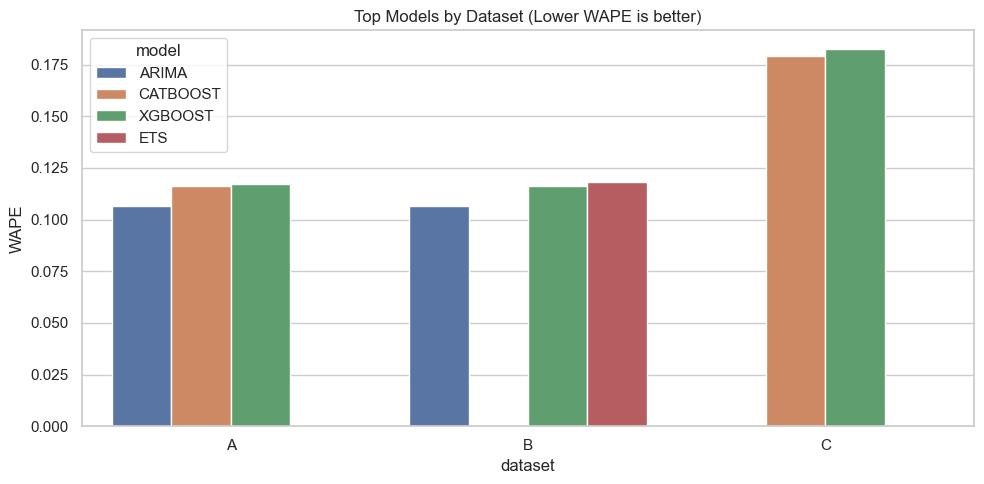

In [9]:
best = lb.sort_values(['dataset','WAPE']).groupby('dataset', as_index=False).head(3)
display(best[['dataset','model','WAPE','MASE_mean','RMSE','Bias','under_forecast_rate']].sort_values(['dataset','WAPE']))

plt.figure(figsize=(10,5))
sns.barplot(data=best.sort_values('WAPE'), x='dataset', y='WAPE', hue='model')
plt.title('Top Models by Dataset (Lower WAPE is better)')
plt.tight_layout()
plt.show()


## 2) Multi-Horizon Accuracy (H+1 / H+2 / H+3)


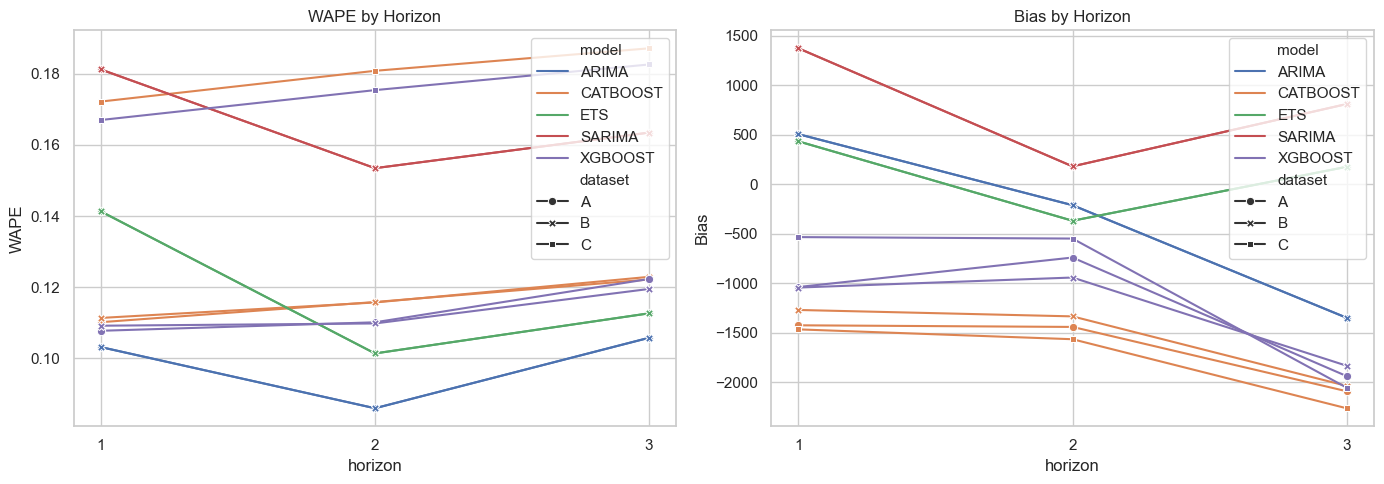

In [10]:
h = byh[byh['horizon'].isin([1,2,3])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.lineplot(data=h, x='horizon', y='WAPE', hue='model', style='dataset', markers=True, dashes=False, ax=axes[0])
axes[0].set_title('WAPE by Horizon')
axes[0].set_xticks([1,2,3])

sns.lineplot(data=h, x='horizon', y='Bias', hue='model', style='dataset', markers=True, dashes=False, ax=axes[1])
axes[1].set_title('Bias by Horizon')
axes[1].set_xticks([1,2,3])

plt.tight_layout()
plt.show()


## 3) Demand Forecast View (P50 + Uncertainty Band)
Pick any dataset/model/SKU for manager review.


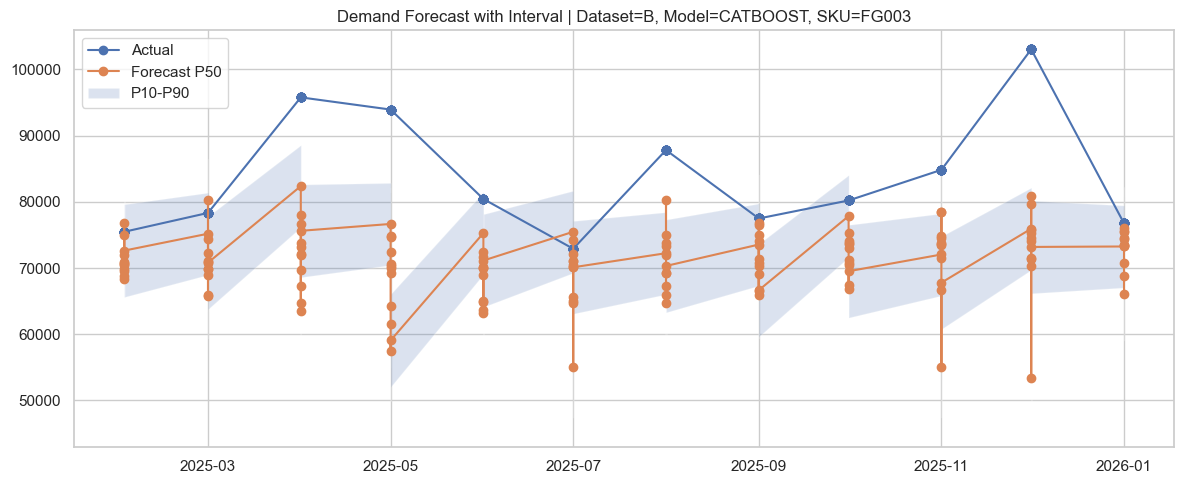

,month,horizon,y_true,forecast_p50,p10,p90
44520,2025-02-01,1,75473.0,74916.303442,68715.139302,81117.467582
45756,2025-02-01,2,75473.0,68745.881727,61874.373625,75617.389828
46992,2025-02-01,3,75473.0,70907.678812,63703.015472,78112.342152
48228,2025-02-01,4,75473.0,71959.982011,64626.452056,79293.511966
49464,2025-02-01,5,75473.0,69792.857635,62331.321466,77254.393804
50700,2025-02-01,6,75473.0,70779.009322,64711.714615,76846.304028
51936,2025-02-01,7,75473.0,76855.461881,70441.581964,83269.341799
53172,2025-02-01,8,75473.0,68295.775926,62219.889081,74371.662771
54408,2025-02-01,9,75473.0,70540.919515,64142.040090,76939.798941
55644,2025-02-01,10,75473.0,69538.303905,63310.928342,75765.679469


In [11]:
dataset_sel = 'B'
model_sel = 'CATBOOST'

sub = fc[(fc['dataset']==dataset_sel) & (fc['model']==model_sel)].copy()

# choose top SKU by demand for this model/dataset
sku = sub.groupby('fg_code')['y_true'].sum().sort_values(ascending=False).index[0]
ss = sub[sub['fg_code']==sku].sort_values(['month','horizon'])

plt.figure(figsize=(12,5))
plt.plot(ss['month'], ss['y_true'], marker='o', label='Actual')
plt.plot(ss['month'], ss['forecast_p50'], marker='o', label='Forecast P50')
plt.fill_between(ss['month'], ss['p10'], ss['p90'], alpha=0.2, label='P10-P90')
plt.title(f'Demand Forecast with Interval | Dataset={dataset_sel}, Model={model_sel}, SKU={sku}')
plt.legend()
plt.tight_layout()
plt.show()

display(ss[['month','horizon','y_true','forecast_p50','p10','p90']].head(15))


## 4) Inventory Action View (ROP, Safety Stock, Suggested Order)


,fg_code,fg_category,forecast_p50,on_hand_inventory,safety_stock,reorder_point,target_max,suggested_order_qty
211,FG006,Soap,63573.490043,93012.0,18776.0,95064.0,158637.0,65625.0
254,FG049,Diaper,57604.058518,85596.0,11685.0,65449.0,123053.0,37457.0
257,FG052,Diaper,59319.788589,77005.0,8525.0,48072.0,107392.0,30387.0
268,FG063,Sanitary,44448.377831,53520.0,4881.0,38958.0,83406.0,29886.0
207,FG002,Soap,45655.882563,74976.0,11448.0,55582.0,101238.0,26262.0
226,FG021,Shampoo,33906.254299,41660.0,7251.0,33246.0,67152.0,25492.0
249,FG044,Diaper,41792.810834,51462.0,5159.0,34414.0,76207.0,24745.0
240,FG035,Liquid Wash,34899.678412,60912.0,10834.0,50387.0,85287.0,24375.0
243,FG038,Liquid Wash,31622.582907,54765.0,7777.0,45724.0,77347.0,22582.0
289,FG084,Home Care,25050.207628,35036.0,4736.0,31456.0,56506.0,21470.0


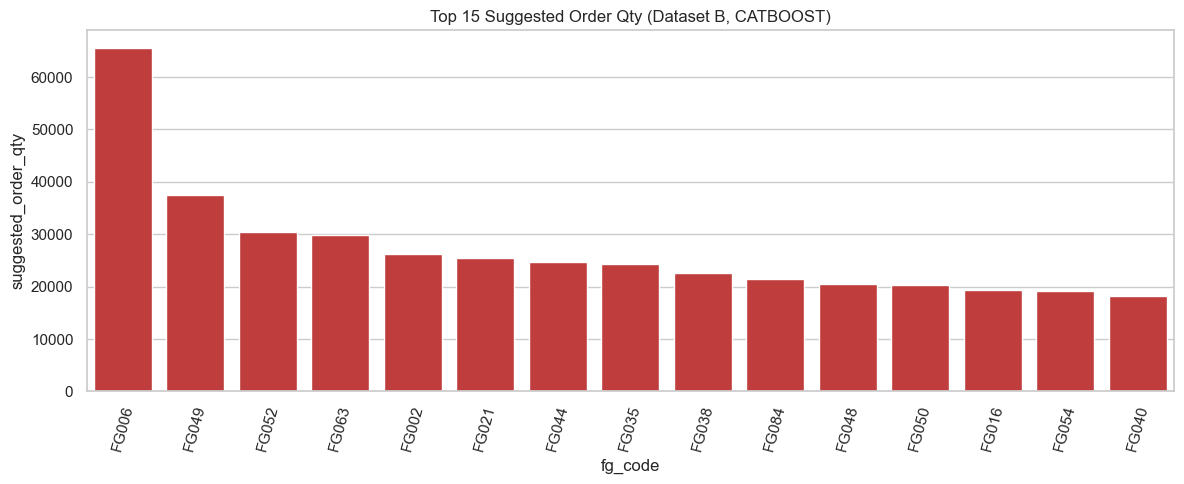

In [12]:
invb = inv[(inv['dataset']=='B') & (inv['model']=='CATBOOST')].copy()

# top actionable: largest suggested orders
actions = invb.sort_values('suggested_order_qty', ascending=False).head(25)
display(actions[['fg_code','fg_category','forecast_p50','on_hand_inventory','safety_stock','reorder_point','target_max','suggested_order_qty']])

plt.figure(figsize=(12,5))
sns.barplot(data=actions.head(15), x='fg_code', y='suggested_order_qty', color='#d62728')
plt.title('Top 15 Suggested Order Qty (Dataset B, CATBOOST)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 5) Risk View (Under-forecast / Over-forecast exposure)


,dataset,model,risk_type,total_abs_error,avg_error
3,A,CATBOOST,Under-forecast,3.581820e+07,-4405.682982
9,A,XGBOOST,Under-forecast,3.459988e+07,-4064.835249
8,A,XGBOOST,Over-forecast,1.916287e+07,3032.099138
2,A,CATBOOST,Over-forecast,1.744355e+07,2602.737274
6,A,SARIMA,Over-forecast,4.490076e+06,6545.300445
7,A,SARIMA,Under-forecast,3.805252e+06,-6918.639154
5,A,ETS,Under-forecast,2.376785e+06,-3623.147863
1,A,ARIMA,Under-forecast,2.221018e+06,-3443.439317
4,A,ETS,Over-forecast,2.134978e+06,3680.996267
0,A,ARIMA,Over-forecast,1.849184e+06,3128.907727


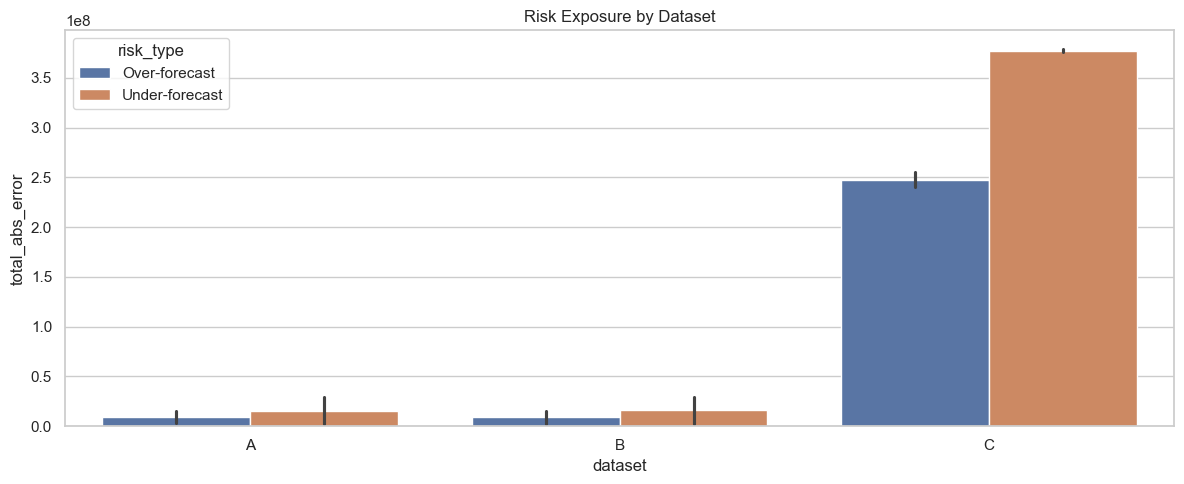

In [13]:
r = fc.copy()
r['error'] = r['forecast_p50'] - r['y_true']
r['abs_error'] = r['error'].abs()
r['risk_type'] = np.where(r['error'] < 0, 'Under-forecast', 'Over-forecast')

risk = (r.groupby(['dataset','model','risk_type'], as_index=False)
          .agg(total_abs_error=('abs_error','sum'), avg_error=('error','mean')))

display(risk.sort_values(['dataset','total_abs_error'], ascending=[True,False]))

plt.figure(figsize=(12,5))
sns.barplot(data=risk, x='dataset', y='total_abs_error', hue='risk_type')
plt.title('Risk Exposure by Dataset')
plt.tight_layout()
plt.show()


## 6) Export Manager Summary Tables


In [14]:
summary_dir = REPORT_DIR

# model summary per dataset
model_summary = lb.sort_values(['dataset','WAPE']).groupby('dataset', as_index=False).head(1)
model_summary.to_csv(summary_dir / 'manager_model_summary.csv', index=False)

# inventory priority list
inv_priority = inv.sort_values('suggested_order_qty', ascending=False).head(200)
inv_priority.to_csv(summary_dir / 'manager_inventory_priority_top200.csv', index=False)

# risk summary
risk_summary = risk.copy()
risk_summary.to_csv(summary_dir / 'manager_risk_summary.csv', index=False)

print('Saved:')
print(summary_dir / 'manager_model_summary.csv')
print(summary_dir / 'manager_inventory_priority_top200.csv')
print(summary_dir / 'manager_risk_summary.csv')


Saved:
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_model_summary.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_inventory_priority_top200.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/manager_risk_summary.csv
